In [42]:
import sys
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [32]:
# Import CSV and convert to pandas dataframe
data_path = "/Users/toripalecek/Documents/metafer_usage/metafer_usage/raw_data/raw_metafer_usage.csv"
data = pd.read_csv(data_path)
df = pd.DataFrame(data)

In [27]:
# View the first 5 rows
data.head()

,case_number,capture_date,scans,metafer
0,26-684_MDSDF,1/2/26 15:17,6,meta2
1,26-697_AMLFA,1/2/26 13:47,10,meta2
2,26-698_AMLFA,1/2/26 13:52,10,Meta7
3,26-1081_EOSMF,1/3/26 13:45,1,Meta1
4,26-1884_AMLFA,1/2/26 13:51,4,meta3


In [28]:
# View the data types and non-null counts of each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6872 entries, 0 to 6871
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   case_number   6872 non-null   str  
 1   capture_date  6872 non-null   str  
 2   scans         6872 non-null   int64
 3   metafer       6872 non-null   str  
dtypes: int64(1), str(3)
memory usage: 214.9 KB


In [11]:
# Check for missing values in the dataframe
df.isnull().sum()

case_number     0
capture_date    0
scans           0
metafer         0
dtype: int64

Imputation is not necessary

In [33]:
# Convert capture_date to datetime format
df['capture_date'] = pd.to_datetime(df['capture_date'])
print(df['capture_date'].dtypes)

datetime64[us]


/var/folders/rr/bmtx3y515yq966zhdj0_1rhw0000gn/T/ipykernel_17919/3189838939.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['capture_date'] = pd.to_datetime(df['capture_date'])


In [36]:
# Create new columns for date, time, time bin, month, weekday, and weekday index
df['date'] = df['capture_date'].dt.date
df['time'] = df['capture_date'].dt.time
# Create a new column for time bins (30-minute intervals)
df['time_bin'] = df['capture_date'].dt.floor('30min').dt.time
df['month'] = df['capture_date'].dt.month
df['weekday'] = df['capture_date'].dt.day_name()
df['weekday_index'] = df['capture_date'].dt.dayofweek
df.head()

,case_number,capture_date,scans,metafer,date,time,time_bin,month,weekday,weekday_index
0,26-684_MDSDF,2026-01-02 15:17:00,6,meta2,2026-01-02,15:17:00,15:00:00,1,Friday,4
1,26-697_AMLFA,2026-01-02 13:47:00,10,meta2,2026-01-02,13:47:00,13:30:00,1,Friday,4
2,26-698_AMLFA,2026-01-02 13:52:00,10,Meta7,2026-01-02,13:52:00,13:30:00,1,Friday,4
3,26-1081_EOSMF,2026-01-03 13:45:00,1,Meta1,2026-01-03,13:45:00,13:30:00,1,Saturday,5
4,26-1884_AMLFA,2026-01-02 13:51:00,4,meta3,2026-01-02,13:51:00,13:30:00,1,Friday,4


In [37]:
# Take just the first metafer
df['metafer'] = df['metafer'].str[:5]

# Standardize the metafer name
df.loc[df['metafer'].str.contains('1'), 'metafer'] = 'meta 1'
df.loc[df['metafer'].str.contains('2'), 'metafer'] = 'meta 2'
df.loc[df['metafer'].str.contains('3'), 'metafer'] = 'meta 3'
df.loc[df['metafer'].str.contains('7'), 'metafer'] = 'meta 7'
df.loc[df['metafer'].str.contains('8'), 'metafer'] = 'meta 8'
df.head(10)

,case_number,capture_date,scans,metafer,date,time,time_bin,month,weekday,weekday_index
0,26-684_MDSDF,2026-01-02 15:17:00,6,meta 2,2026-01-02,15:17:00,15:00:00,1,Friday,4
1,26-697_AMLFA,2026-01-02 13:47:00,10,meta 2,2026-01-02,13:47:00,13:30:00,1,Friday,4
2,26-698_AMLFA,2026-01-02 13:52:00,10,meta 7,2026-01-02,13:52:00,13:30:00,1,Friday,4
3,26-1081_EOSMF,2026-01-03 13:45:00,1,meta 1,2026-01-03,13:45:00,13:30:00,1,Saturday,5
4,26-1884_AMLFA,2026-01-02 13:51:00,4,meta 3,2026-01-02,13:51:00,13:30:00,1,Friday,4
5,26-1888_MDSDF,2026-01-02 15:46:00,6,meta 2,2026-01-02,15:46:00,15:30:00,1,Friday,4
6,26-1892_BLPMF,2026-01-03 12:59:00,2,meta 2,2026-01-03,12:59:00,12:30:00,1,Saturday,5
7,26-1901_HEMMF,2026-01-03 12:15:00,1,meta 2,2026-01-03,12:15:00,12:00:00,1,Saturday,5
8,26-1903_AMLFA,2026-01-02 14:11:00,3,meta 3,2026-01-02,14:11:00,14:00:00,1,Friday,4
9,26-1908_PHLFD,2026-01-02 14:38:00,6,meta 1,2026-01-02,14:38:00,14:30:00,1,Friday,4


In [66]:
# Check the unique values in the metafer column
df['metafer'].value_counts()

metafer
meta 1    1606
meta 3    1554
meta 7    1329
meta 8    1108
meta 2     974
meta4      193
meta5       39
meta6       36
meta9       30
DGS99        2
JLC          1
Name: count, dtype: int64

In [67]:
drop_metas = ['meta4', 'meta5', 'meta6', 'meta9', 'DGS99', 'JLC']

for meta in drop_metas:
    df = df[df['metafer'] != meta]

df['metafer'].value_counts()

metafer
meta 1    1606
meta 3    1554
meta 7    1329
meta 8    1108
meta 2     974
Name: count, dtype: int64

In [68]:
# Group the data by month and date, and calculate the total number of scans for each day
daily_totals = (
    df.groupby(['month', 'date'], as_index=False)['scans']
      .sum()
)
print(daily_totals.head(10))

   month        date  scans
0      1  2026-01-02     57
1      1  2026-01-03    189
2      1  2026-01-04    139
3      1  2026-01-05     81
4      1  2026-01-06     57
5      1  2026-01-07    237
6      1  2026-01-08    320
7      1  2026-01-09    284
8      1  2026-01-10    170
9      1  2026-01-11    123


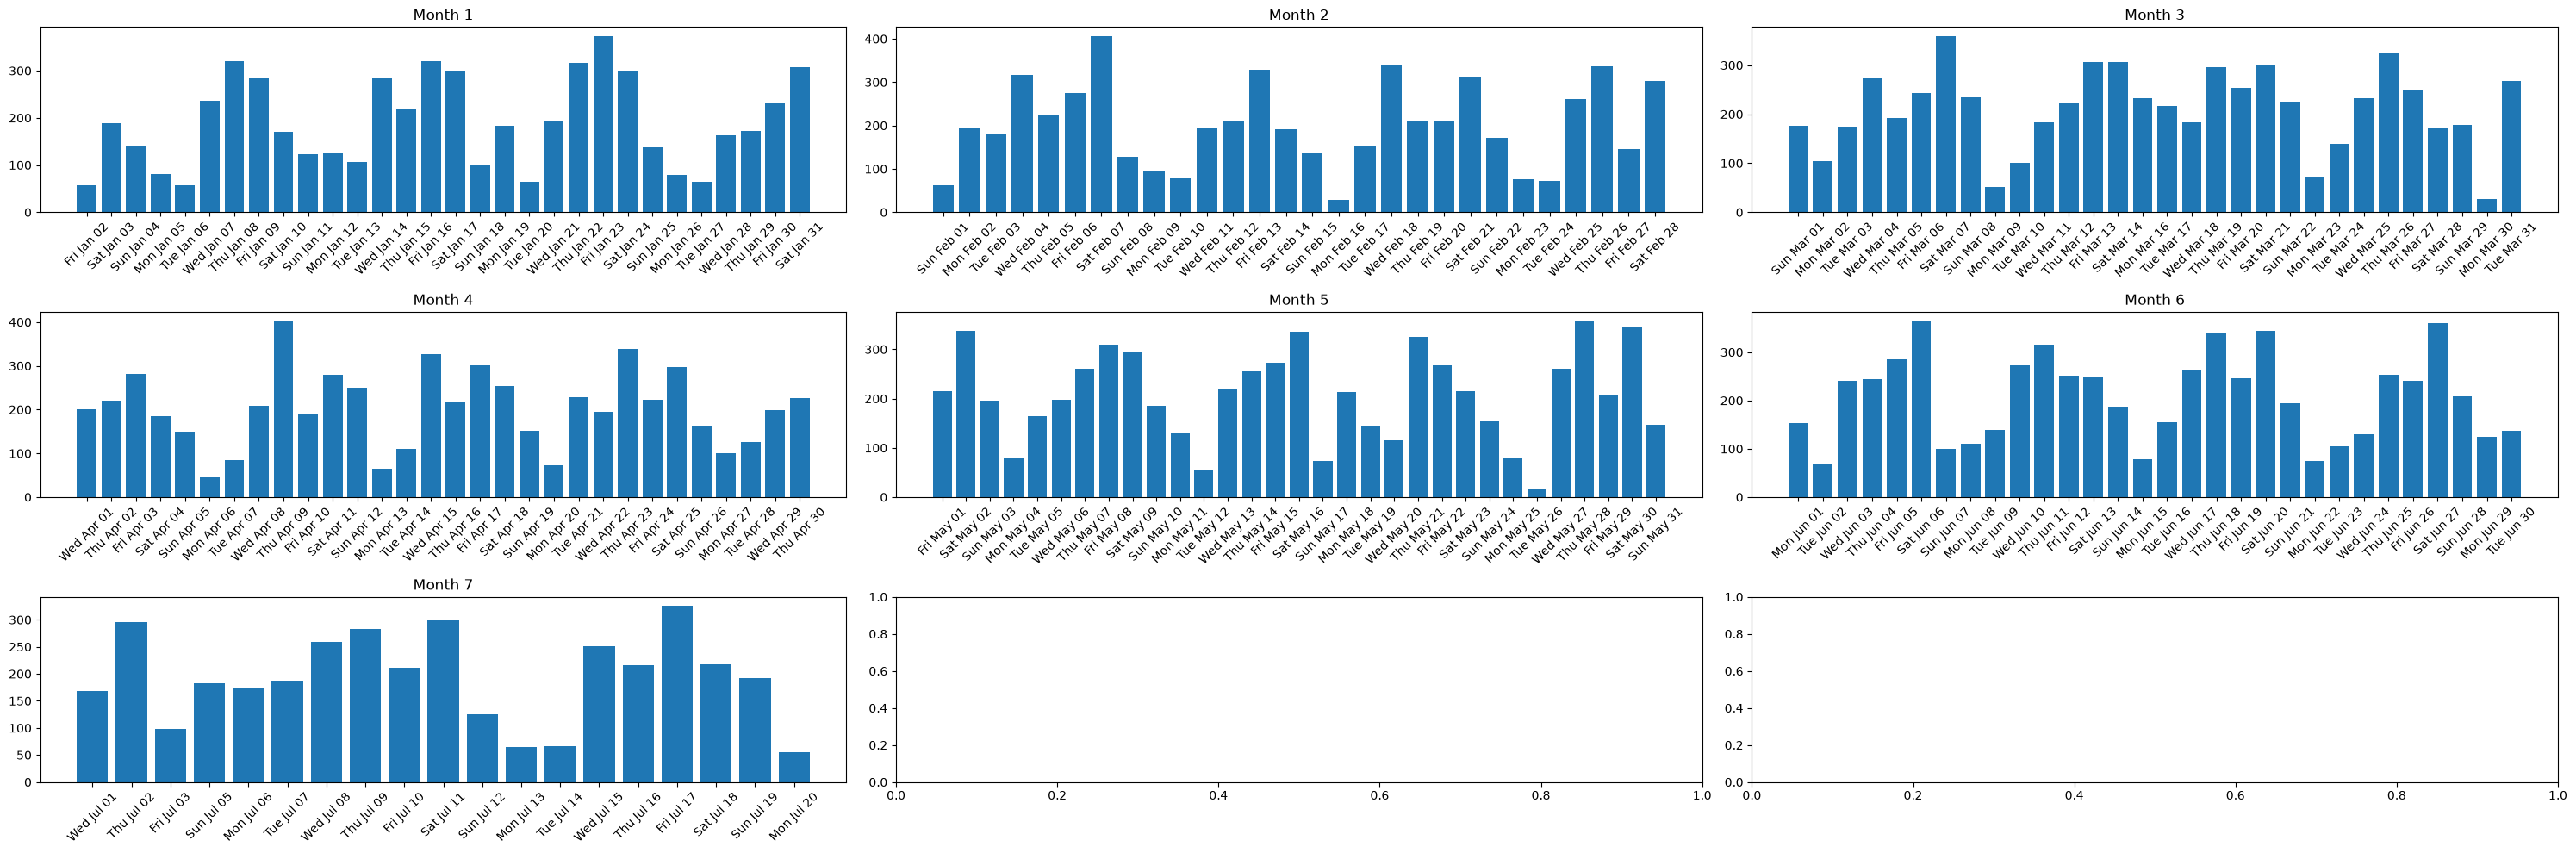

In [69]:
# Convert the 'date' column to datetime format for plotting
daily_totals['date'] = pd.to_datetime(daily_totals['date'])

# Create a bar plot for each month showing the total number of scans per day
fig, axes = plt.subplots(3, 3, figsize=(30, 10))
axes = axes.flatten()

for i, (month, data) in enumerate(daily_totals.groupby('month')):
    ax = axes[i]

    ax.bar(
        data['date'].dt.strftime('%a %b %d'),
        data['scans']
    )

    ax.set_title(f"Month {month}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

There are no abnormal months. All rows can be kept for further analysis.

In [74]:
weekday_metafer_totals = (
    df.groupby(['weekday_index', 'metafer'], as_index=False)['scans']
      .mean()
)
print(weekday_metafer_totals.head(10))

   weekday_index metafer     scans
0              0  meta 1  5.976378
1              0  meta 2  7.000000
2              0  meta 3  5.451128
3              0  meta 7  5.436364
4              0  meta 8  6.126984
5              1  meta 1  5.686567
6              1  meta 2  6.524590
7              1  meta 3  5.494792
8              1  meta 7  5.021583
9              1  meta 8  5.054545


In [75]:
# Create a pivot table to show the average number of scans for each metafer on each day of the week
weekday_totals_pivot = weekday_metafer_totals.pivot(
    index='weekday_index', 
    columns='metafer', 
    values='scans')

print(weekday_totals_pivot.head(10))

metafer          meta 1    meta 2    meta 3    meta 7    meta 8
weekday_index                                                  
0              5.976378  7.000000  5.451128  5.436364  6.126984
1              5.686567  6.524590  5.494792  5.021583  5.054545
2              5.978102  7.045872  5.957082  5.590909  6.564516
3              6.135922  6.470874  6.080420  5.894068  5.732719
4              6.086505  6.508475  6.235915  6.168103  5.663212
5              6.238506  5.697674  6.679715  6.120930  5.186667
6              8.064000  7.527473  6.917241  6.509677  6.719298


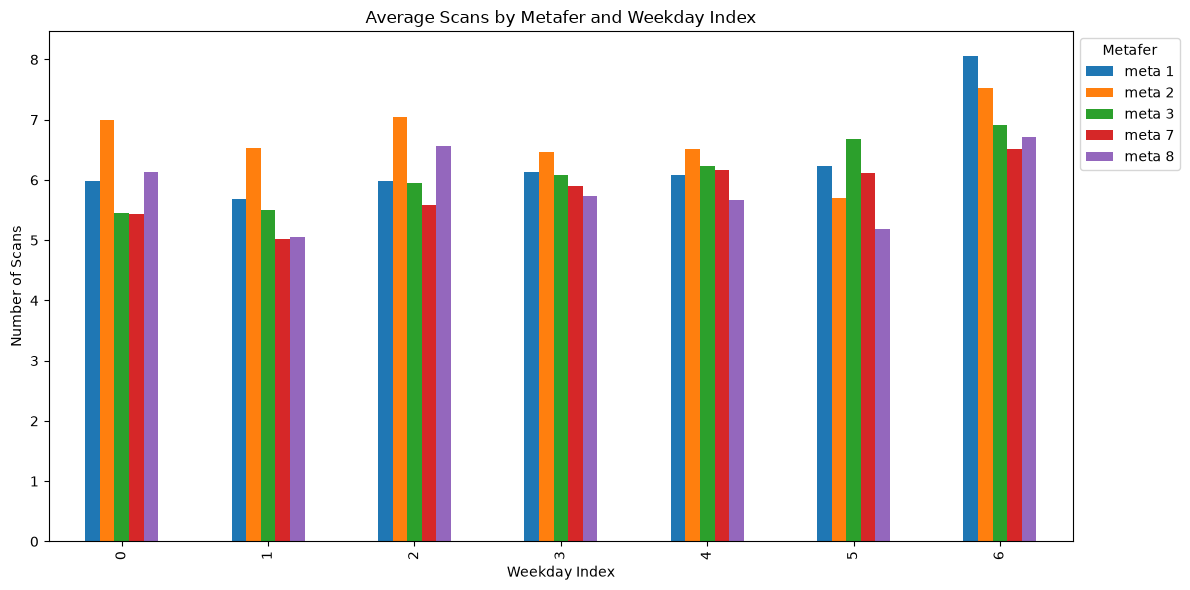

In [ ]:
# Create a bar plot to visualize the average number of scans for each metafer on each day of the week
weekday_totals_pivot.plot(kind='bar',figsize=(12,6))
plt.title(f"Average Scans by Metafer and Weekday Index")
plt.xlabel("Weekday Index")
plt.ylabel("Number of Scans")
plt.legend(title="Metafer", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [ ]:
# Create a function to assign shifts based on times from the time bins. 0300-1430 is day shift, 1431-0259 is night shift
def assign_shift(t):
    if pd.to_datetime('03:00').time() <= t <= pd.to_datetime('14:30').time():
        return 'Day'
    else:
        return 'Night'

df['shift'] = df['time_bin'].apply(assign_shift)


In [85]:
# Split the dataframe into two separate dataframes for day and night shifts
am_df = df[df['shift'] == 'Day']
pm_df = df[df['shift'] == 'Night']
pm_df.head()

,case_number,capture_date,scans,metafer,date,time,time_bin,month,weekday,weekday_index,shift
0,26-684_MDSDF,2026-01-02 15:17:00,6,meta 2,2026-01-02,15:17:00,15:00:00,1,Friday,4,Night
5,26-1888_MDSDF,2026-01-02 15:46:00,6,meta 2,2026-01-02,15:46:00,15:30:00,1,Friday,4,Night
50,26-29536_PHLFD,2026-01-04 15:06:00,5,meta 8,2026-01-04,15:06:00,15:00:00,1,Sunday,6,Night
52,26-29539_PHLFD,2026-01-04 15:38:00,6,meta 8,2026-01-04,15:38:00,15:30:00,1,Sunday,6,Night
58,26-15479_TALMF,2026-01-04 16:15:00,1,meta 8,2026-01-04,16:15:00,16:00:00,1,Sunday,6,Night


In [87]:
# Calculate the average number of scans for each metafer by weekday for day and night shifts
am_weekday_metafer_totals = (
    am_df.groupby(['weekday_index', 'metafer'], as_index=False)['scans']
      .mean()
)
pm_weekday_metafer_totals = (
    pm_df.groupby(['weekday_index', 'metafer'], as_index=False)['scans']
      .mean()
)

In [89]:
# Create pivot tables for day and night shifts to show the average number of scans for each metafer on each day of the week
am_weekday_totals_pivot = am_weekday_metafer_totals.pivot(
    index='weekday_index', 
    columns='metafer', 
    values='scans')

pm_weekday_totals_pivot = pm_weekday_metafer_totals.pivot(
    index='weekday_index', 
    columns='metafer', 
    values='scans')

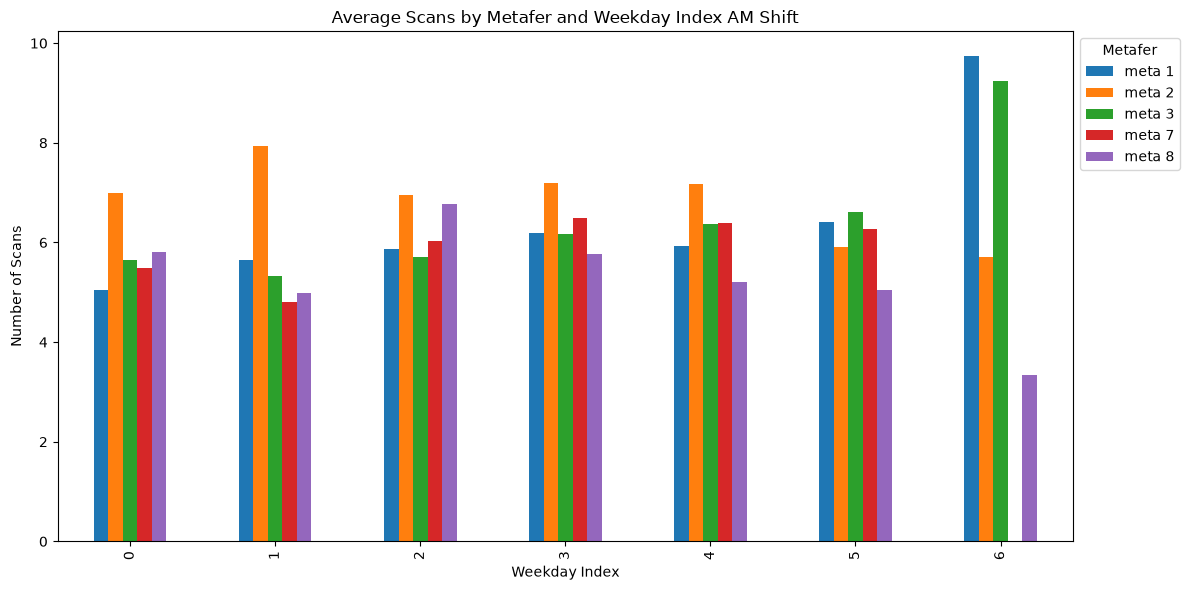

In [93]:
am_weekday_totals_pivot.plot(kind='bar',figsize=(12,6))
plt.title(f"Average Scans by Metafer and Weekday Index AM Shift")
plt.xlabel("Weekday Index")
plt.ylabel("Number of Scans")
plt.legend(title="Metafer", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

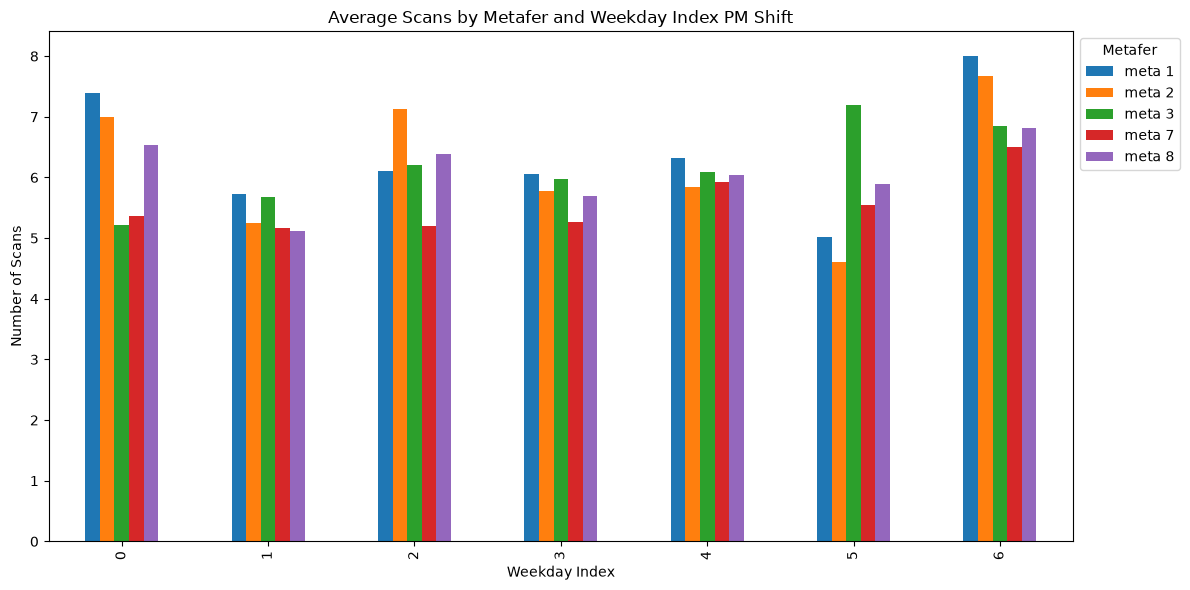

In [92]:
pm_weekday_totals_pivot.plot(kind='bar',figsize=(12,6))
plt.title(f"Average Scans by Metafer and Weekday Index PM Shift")
plt.xlabel("Weekday Index")
plt.ylabel("Number of Scans")
plt.legend(title="Metafer", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [ ]:
# Make groups by metafer used, day of the week and time bin (time aggregation)
""" The average sites column is indicative of how many sites scanned
during that 30 minute time bin. A scanner can scan approximately 1 site
every 5 minutes. A full frame is equivalent to approsimatley 1 hour of scan
time. The threshold for what constitutes an active scanner will be based on
scans in relation to frame capacity.
"""
usage_meta_day_time = (
    df.groupby(['weekday', 'metafer', 'time_bin'])
      .agg(
          sites=('scans', 'mean'))
      ).reset_index()

usage_meta_day_time.head()

,weekday,metafer,time_bin,sites
0,Friday,meta 1,00:00:00,6.923077
1,Friday,meta 1,00:30:00,7.428571
2,Friday,meta 1,01:00:00,6.400000
3,Friday,meta 1,01:30:00,5.500000
4,Friday,meta 1,02:00:00,6.200000


In [143]:
# Make groups by day of the week and time bin (time aggregation)
usage_day_time = (
    df.groupby(['weekday','time_bin'])
      .agg(
          sites=('scans', 'mean'))
      ).reset_index()

usage_day_time.head()

,weekday,time_bin,sites
0,Friday,00:00:00,6.301370
1,Friday,00:30:00,6.643564
2,Friday,01:00:00,6.202128
3,Friday,01:30:00,6.026667
4,Friday,02:00:00,5.921053


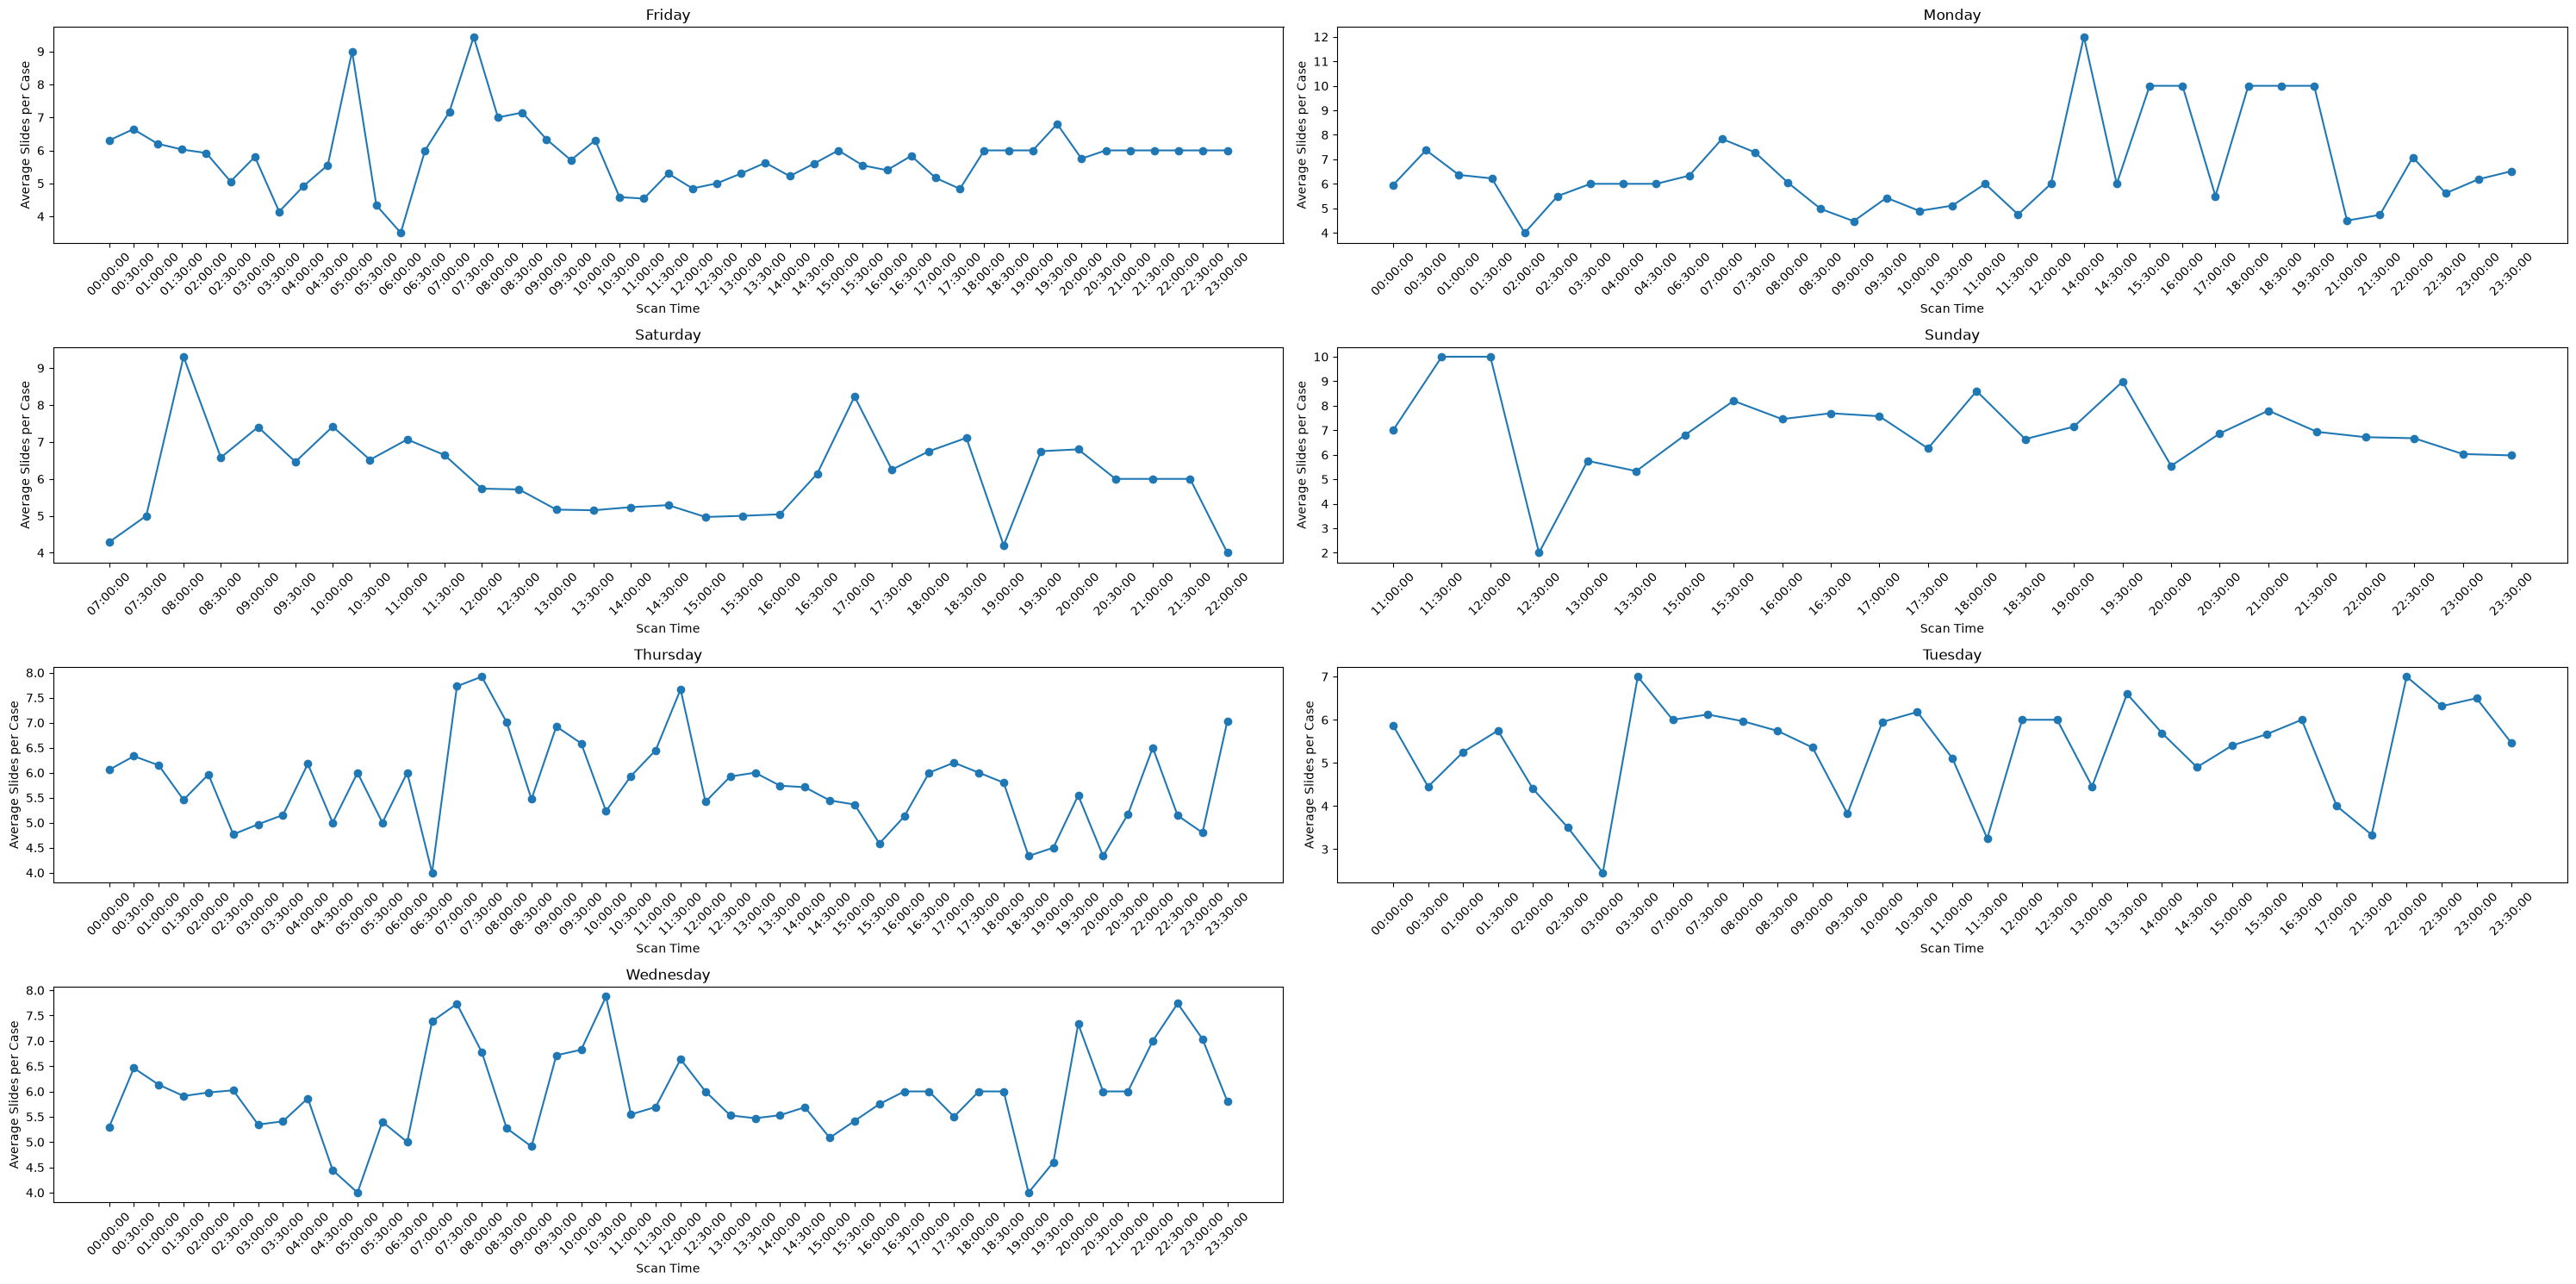

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(30, 15))
axes = axes.flatten()

for i, (day, data) in enumerate(usage_day_time.groupby('weekday')):
    ax = axes[i]

    ax.plot(
        data['time_bin'].astype(str),
        data['sites'],
        marker='o'
    )

    ax.set_title(day)
    ax.set_xlabel("Scan Time")
    ax.set_ylabel("Average Sites Scanned")
    ax.tick_params(axis='x', rotation=45)

# Remove unused subplot if you have one
for j in range(i + 1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

In [144]:
#threshold = (usage_day_time['sites'].quantile(0.25))

# Define threshold as the number of sites that can reasonably be scanned in a 30 minute time bin
threshold = 6
usage_day_time['active'] = (usage_day_time['sites']>threshold)
usage_day_time.head()

,weekday,time_bin,sites,active
0,Friday,00:00:00,6.301370,True
1,Friday,00:30:00,6.643564,True
2,Friday,01:00:00,6.202128,True
3,Friday,01:30:00,6.026667,True
4,Friday,02:00:00,5.921053,False


In [145]:
# Find active windows of usage by metafer and weekday. This will help identify the time bins where scanners are actively being used.
windows = (usage_day_time[usage_day_time['active']].groupby(['weekday']).agg(
	start_time=("time_bin","min"),
	end_time=("time_bin","max"),
	avg_sites=('sites','mean')).reset_index())
windows.head(20)

,weekday,start_time,end_time,avg_sites
0,Friday,00:00:00,19:30:00,7.030955
1,Monday,00:30:00,23:30:00,8.078048
2,Saturday,08:00:00,20:00:00,7.029009
3,Sunday,11:00:00,23:00:00,7.545626
4,Thursday,00:00:00,23:30:00,6.765887
5,Tuesday,03:30:00,23:00:00,6.531366
6,Wednesday,00:30:00,23:00:00,6.976280


In [146]:
# sort data by weekday and time bin for easier visualization
usage_day_time = usage_day_time.sort_values(
    ['weekday', 'time_bin']
)

In [147]:
# Create a new column called window_id that assigns a unique identifier to each active window of usage. This is done by checking if the 'active' status has changed from the previous row and cumulatively summing the changes to create a unique ID for each window.
usage_day_time['window_id'] = (
    usage_day_time['active']
    .ne(usage_day_time['active'].shift())
    .cumsum()
)

In [148]:
# Create a new dataframe that contains only the rows where the scanner is active
active_windows = usage_day_time[
    usage_day_time['active']
]

In [150]:
windows_all = (
    active_windows
    .groupby(['weekday', 'window_id'])
    .agg(
        start_time=('time_bin','min'),
        end_time=('time_bin','max'),
        avg_sites=('sites','mean')
    )
    .reset_index()
)
print(windows_all.head(20))

     weekday  window_id start_time  end_time  avg_sites
0     Friday          1   00:00:00  01:30:00   6.293432
1     Friday          3   05:00:00  05:00:00   9.000000
2     Friday          5   07:00:00  09:00:00   7.418434
3     Friday          7   10:00:00  10:00:00   6.305556
4     Friday          9   19:30:00  19:30:00   6.800000
5     Monday         11   00:30:00  01:30:00   6.653620
6     Monday         13   06:30:00  08:00:00   6.875595
7     Monday         15   14:00:00  14:00:00  12.000000
8     Monday         17   15:30:00  16:00:00  10.000000
9     Monday         19   18:00:00  19:30:00  10.000000
10    Monday         21   22:00:00  22:00:00   7.083333
11    Monday         23   23:00:00  23:30:00   6.351096
12  Saturday         25   08:00:00  11:30:00   7.175050
13  Saturday         27   16:30:00  18:30:00   6.896947
14  Saturday         29   19:30:00  20:00:00   6.775000
15    Sunday         31   11:00:00  12:00:00   9.000000
16    Sunday         33   15:00:00  19:30:00   7

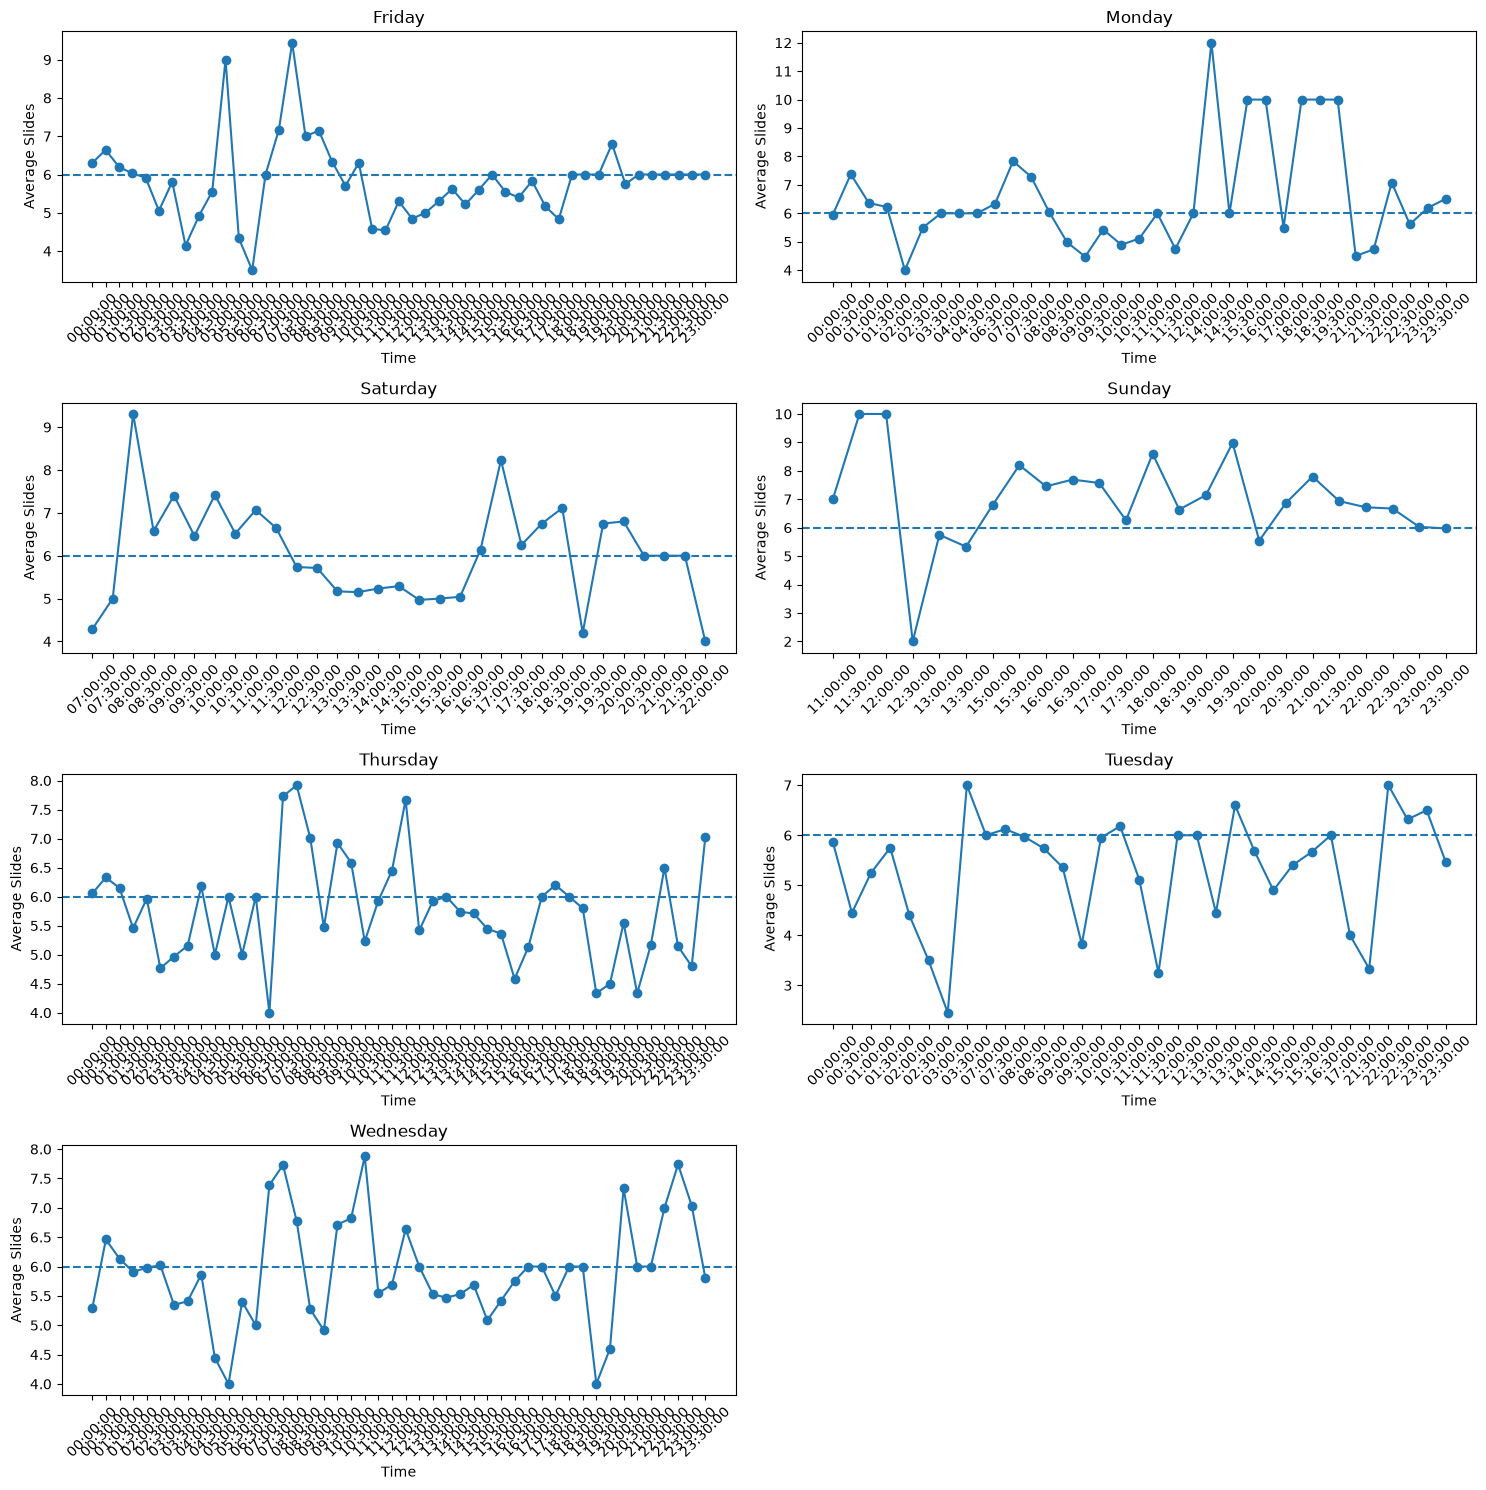

In [ ]:
# Add a threshold line to the scanning times plot
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
axes = axes.flatten()

for i, (day, data) in enumerate(usage_day_time.groupby('weekday')):
    ax = axes[i]

    ax.plot(
        data['time_bin'].astype(str),
        data['sites'],
        marker='o'
    )

    # Add a line showing the active threshold
    ax.axhline(
        threshold,
        linestyle='--'
    )

    ax.set_title(day)
    ax.set_xlabel("Time")
    ax.set_ylabel("Average Slides")
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()